In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
train_df = pd.read_csv("/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train.csv")
coordinate_df= pd.read_csv("/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_label_coordinates.csv")
series_desc_df= pd.read_csv("/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_series_descriptions.csv")
test = pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/test_series_descriptions.csv')
# sample_submission = pd.read_csv('/path/to/sample_submission.csv')
sample_submission=pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/sample_submission.csv')

In [11]:
train_df.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


In [12]:
coordinate_df.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


In [13]:
series_desc_df.shape

(6294, 3)

In [14]:
series_desc_df.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [15]:
import os
import pydicom
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

In [16]:
dicom_dir = '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240'
dicom_files = glob(os.path.join(dicom_dir, '**/*.dcm'), recursive=True)

# Print out some file paths
print(f"Total DICOM files found: {len(dicom_files)}")
print(dicom_files[:5])  # Display the first 5 DICOM file paths

Total DICOM files found: 42
['/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/12.dcm', '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/18.dcm', '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/9.dcm', '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/22.dcm', '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/25.dcm']


In [17]:
files_in_dir = os.listdir(dicom_dir)
files_in_dir

['12.dcm',
 '18.dcm',
 '9.dcm',
 '22.dcm',
 '25.dcm',
 '39.dcm',
 '14.dcm',
 '11.dcm',
 '24.dcm',
 '34.dcm',
 '29.dcm',
 '23.dcm',
 '41.dcm',
 '35.dcm',
 '10.dcm',
 '28.dcm',
 '37.dcm',
 '17.dcm',
 '30.dcm',
 '1.dcm',
 '15.dcm',
 '2.dcm',
 '36.dcm',
 '8.dcm',
 '7.dcm',
 '21.dcm',
 '33.dcm',
 '5.dcm',
 '4.dcm',
 '42.dcm',
 '31.dcm',
 '38.dcm',
 '19.dcm',
 '27.dcm',
 '6.dcm',
 '16.dcm',
 '20.dcm',
 '40.dcm',
 '3.dcm',
 '32.dcm',
 '26.dcm',
 '13.dcm']

In [18]:
dicom_files[0:6]

['/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/12.dcm',
 '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/18.dcm',
 '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/9.dcm',
 '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/22.dcm',
 '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/25.dcm',
 '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/4287160193/1820446240/39.dcm']

In [19]:
dicom_file_path = dicom_files[15]
dicom_data = pydicom.dcmread(dicom_file_path)
# Print all the available metadata
print(dicom_data)

Dataset.file_meta -------------------------------
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 4287160193.1.28
(0002, 0010) Transfer Syntax UID                 UI: RLE Lossless
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002, 0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008, 0018) SOP Instance UID                    UI: 4287160193.1.28
(0008, 0023) Content Date                        DA: '20240503'
(0008, 0033) Content Time                        TM: '224057.280875'
(0008, 103e) Series Description                  LO: 'T2'
(0010, 0020) Patient ID                          LO: '4287160193'
(0018, 0050) Slice Thickness                     DS: '4.0'
(0018, 0088) Spacing Between Slices              DS: '5.0'
(0018, 5100) Patient Position        

In [20]:
print(dir(dicom_data))

['BitsAllocated', 'BitsStored', 'Columns', 'ContentDate', 'ContentTime', 'FrameOfReferenceUID', 'HighBit', 'ImageOrientationPatient', 'ImagePositionPatient', 'InstanceNumber', 'PatientID', 'PatientPosition', 'PhotometricInterpretation', 'PixelData', 'PixelRepresentation', 'PixelSpacing', 'Rows', 'SOPInstanceUID', 'SamplesPerPixel', 'SeriesDescription', 'SeriesInstanceUID', 'SliceLocation', 'SliceThickness', 'SpacingBetweenSlices', 'StudyInstanceUID', 'WindowCenter', 'WindowWidth', '__array__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__setstate__', '__sizeof__', '__str__', '__subcl

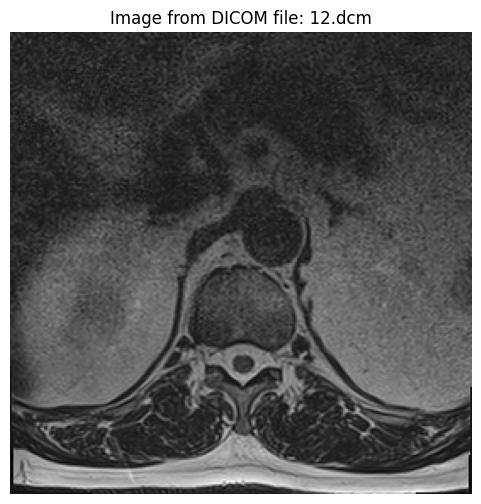

In [21]:
# Load one DICOM file
sample_dicom = pydicom.dcmread(dicom_files[5])

# Visualize the image using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(sample_dicom.pixel_array, cmap='gray')
plt.title(f"Image from DICOM file: {os.path.basename(dicom_files[0])}")
plt.axis('off')
plt.show()

In [22]:
# Print basic DICOM metadata
print(f"Patient ID: {sample_dicom.PatientID}")
print(f"Image Dimensions: {sample_dicom.Rows} x {sample_dicom.Columns}")
print(f"Pixel Spacing: {sample_dicom.PixelSpacing}")
print(f"Slice Thickness: {sample_dicom.SliceThickness}")
print(f"Series Description: {sample_dicom.SeriesDescription}")

Patient ID: 4287160193
Image Dimensions: 272 x 272
Pixel Spacing: [0.7353, 0.7353]
Slice Thickness: 4.0000
Series Description: T2


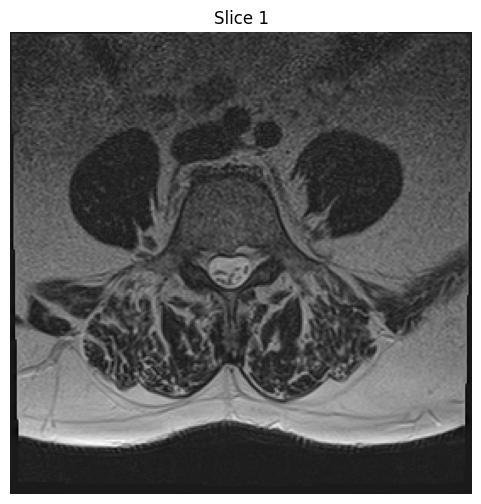

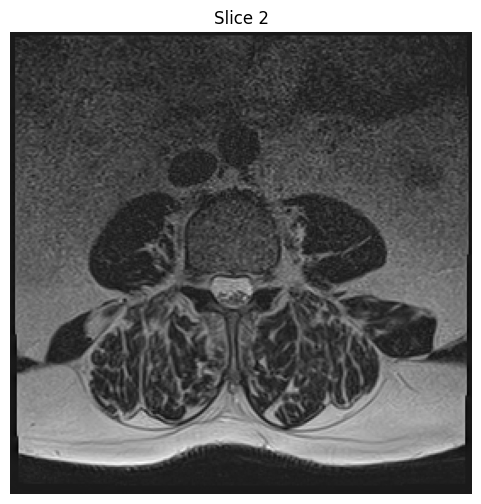

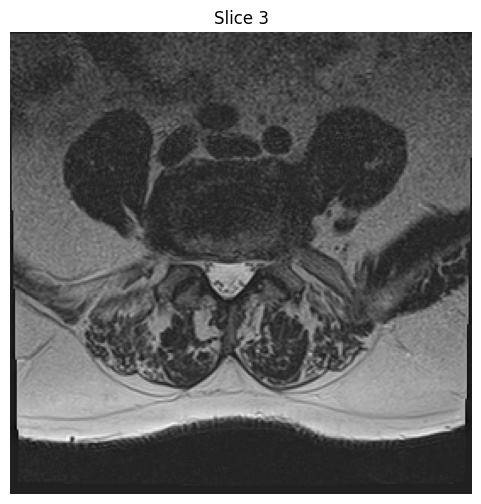

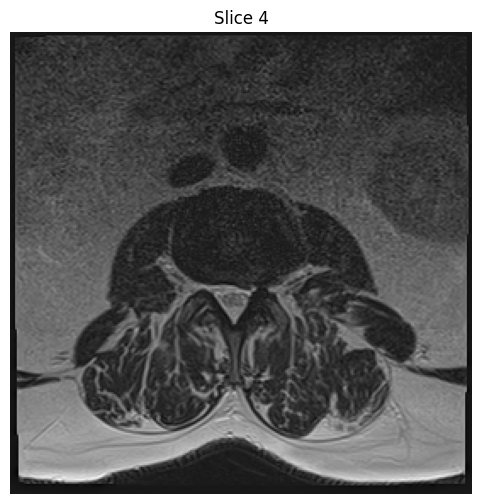

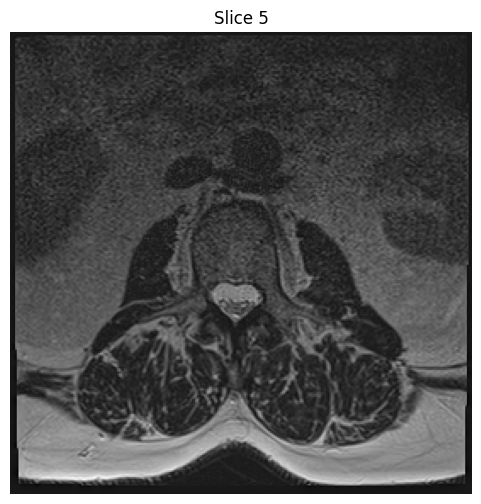

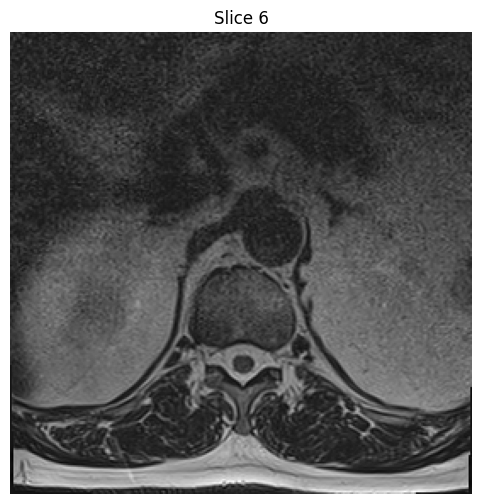

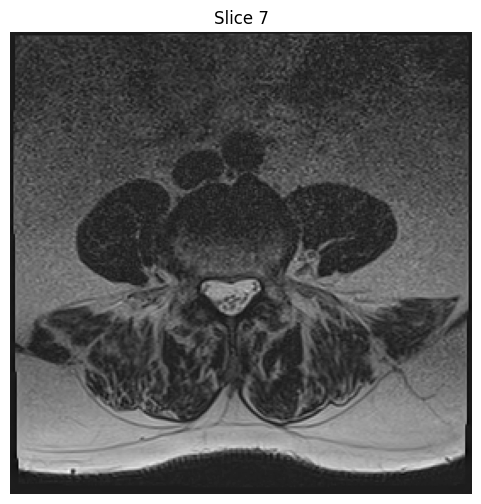

In [23]:
for i, dicom_file in enumerate(dicom_files[:7]):  # Visualize first 5 slices
    dicom_slice = pydicom.dcmread(dicom_file)
    plt.figure(figsize=(6, 6))
    plt.imshow(dicom_slice.pixel_array, cmap='gray')
    plt.title(f"Slice {i + 1}")
    plt.axis('off')
    plt.show()

# --------------------------------------------------------------

# checking for missing or incomplete labels in your train.csv

In [24]:
import pandas as pd

# Load the train.csv file
train_df = pd.read_csv('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train.csv')

In [25]:
train_df.shape

(1975, 26)

In [26]:
train_df.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


In [27]:
# Check for missing values in the dataset
missing_values = train_df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 study_id                                    0
spinal_canal_stenosis_l1_l2                 1
spinal_canal_stenosis_l2_l3                 1
spinal_canal_stenosis_l3_l4                 1
spinal_canal_stenosis_l4_l5                 1
spinal_canal_stenosis_l5_s1                 1
left_neural_foraminal_narrowing_l1_l2       2
left_neural_foraminal_narrowing_l2_l3       2
left_neural_foraminal_narrowing_l3_l4       2
left_neural_foraminal_narrowing_l4_l5       2
left_neural_foraminal_narrowing_l5_s1       2
right_neural_foraminal_narrowing_l1_l2      8
right_neural_foraminal_narrowing_l2_l3      8
right_neural_foraminal_narrowing_l3_l4      8
right_neural_foraminal_narrowing_l4_l5      8
right_neural_foraminal_narrowing_l5_s1      8
left_subarticular_stenosis_l1_l2          164
left_subarticular_stenosis_l2_l3           82
left_subarticular_stenosis_l3_l4            3
left_subarticular_stenosis_l4_l5            3
left_subarticular_stenosis_l5_s1           11
right_

In [28]:
missing_rows = train_df[train_df.isnull().any(axis=1)]
# print("Rows with missing labels:\n", missing_rows)
missing_rows.head(10)

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
16,46494080,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,NaN,NaN,Normal/Mild,Moderate,Moderate,NaN,NaN,Moderate,Moderate,Normal/Mild
24,64092030,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,NaN,Normal/Mild,NaN,Moderate,Moderate,NaN,Moderate,NaN,Normal/Mild,Normal/Mild
30,74782131,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,NaN,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,NaN,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
43,97086905,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,NaN,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,NaN,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
73,159721286,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,NaN,NaN,Normal/Mild,Moderate,Normal/Mild,NaN,NaN,Moderate,Severe,Normal/Mild
109,228290246,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Moderate,Moderate,...,Severe,Moderate,Moderate,Severe,NaN,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
135,293713262,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,NaN,NaN,Severe,Moderate,Normal/Mild,NaN,NaN,Moderate,Moderate,Normal/Mild
136,296083289,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,NaN,Moderate,Severe,Severe,Severe,NaN,Normal/Mild,Moderate,Moderate,Normal/Mild
137,296284854,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,NaN,Normal/Mild,Moderate,Severe,Moderate,NaN,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
140,305152236,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,NaN,Normal/Mild,Moderate,Severe,Normal/Mild,NaN,Normal/Mild,Normal/Mild,Severe,Severe


In [29]:
missing_rows_specific = train_df[train_df['right_neural_foraminal_narrowing_l4_l5'].isnull()]
# print("Rows with missing values in 'right_subarticular_stenosis_l2_l3':\n", missing_rows)
missing_rows_specific

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
217,462494704,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild
226,482624307,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
348,779042451,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1126,2492114990,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,NaN,NaN,NaN,NaN,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1135,2507107985,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
1188,2607462358,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,Severe,...,Moderate,Severe,Severe,Severe,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
1272,2780132468,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,NaN,NaN,NaN,NaN,...,Moderate,Moderate,Moderate,Moderate,Normal/Mild,Severe,Moderate,Normal/Mild,Moderate,Normal/Mild
1740,3781188430,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,Moderate,...,Normal/Mild,Severe,Severe,Severe,Moderate,Normal/Mild,Moderate,Normal/Mild,Severe,Severe


<Axes: >

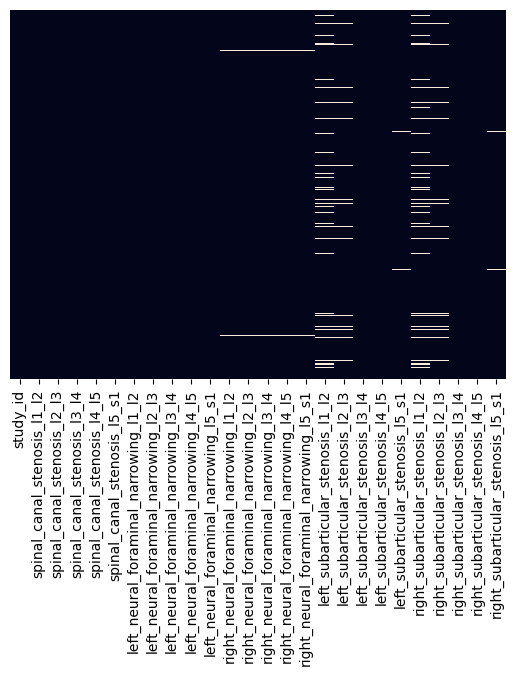

In [30]:
sns.heatmap(train_df.isnull(),yticklabels=False,cbar=False)

In [31]:
train_df['right_subarticular_stenosis_l1_l2'].value_counts()

right_subarticular_stenosis_l1_l2
Normal/Mild    1680
Moderate        110
Severe           24
Name: count, dtype: int64

In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   study_id                                1975 non-null   int64 
 1   spinal_canal_stenosis_l1_l2             1974 non-null   object
 2   spinal_canal_stenosis_l2_l3             1974 non-null   object
 3   spinal_canal_stenosis_l3_l4             1974 non-null   object
 4   spinal_canal_stenosis_l4_l5             1974 non-null   object
 5   spinal_canal_stenosis_l5_s1             1974 non-null   object
 6   left_neural_foraminal_narrowing_l1_l2   1973 non-null   object
 7   left_neural_foraminal_narrowing_l2_l3   1973 non-null   object
 8   left_neural_foraminal_narrowing_l3_l4   1973 non-null   object
 9   left_neural_foraminal_narrowing_l4_l5   1973 non-null   object
 10  left_neural_foraminal_narrowing_l5_s1   1973 non-null   object
 11  righ

# 1. Impute Missing Values (< 20 Missing Rows):

In [33]:
# Impute missing values for columns with < 20 missing values using the most frequent value
minimal_missing_cols = ['spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4',
                        'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1', 'left_neural_foraminal_narrowing_l1_l2',
                        'left_neural_foraminal_narrowing_l2_l3', 'left_neural_foraminal_narrowing_l3_l4',
                        'left_neural_foraminal_narrowing_l4_l5', 'left_neural_foraminal_narrowing_l5_s1', 
                        'right_neural_foraminal_narrowing_l1_l2', 'right_neural_foraminal_narrowing_l2_l3', 
                        'right_neural_foraminal_narrowing_l3_l4', 'right_neural_foraminal_narrowing_l4_l5', 
                        'right_neural_foraminal_narrowing_l5_s1', 'left_subarticular_stenosis_l3_l4',
                        'left_subarticular_stenosis_l4_l5','left_subarticular_stenosis_l5_s1','right_subarticular_stenosis_l3_l4',
                        'right_subarticular_stenosis_l4_l5','right_subarticular_stenosis_l5_s1']

# Impute using the most frequent value (mode) for these columns
for col in minimal_missing_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

/tmp/ipykernel_38/2559284812.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)


# 2. Drop Rows for High Missing Values (> 20 Missing Rows):

In [34]:
# Drop rows with missing values in these columns with high missing values
high_missing_cols = ['left_subarticular_stenosis_l1_l2', 'left_subarticular_stenosis_l2_l3', 
                     'right_subarticular_stenosis_l1_l2', 'right_subarticular_stenosis_l2_l3']

# Drop rows where any of these columns have missing values
train_df_cleaned = train_df.dropna(subset=high_missing_cols)

In [35]:
train_df_cleaned.isnull().sum()

study_id                                  0
spinal_canal_stenosis_l1_l2               0
spinal_canal_stenosis_l2_l3               0
spinal_canal_stenosis_l3_l4               0
spinal_canal_stenosis_l4_l5               0
spinal_canal_stenosis_l5_s1               0
left_neural_foraminal_narrowing_l1_l2     0
left_neural_foraminal_narrowing_l2_l3     0
left_neural_foraminal_narrowing_l3_l4     0
left_neural_foraminal_narrowing_l4_l5     0
left_neural_foraminal_narrowing_l5_s1     0
right_neural_foraminal_narrowing_l1_l2    0
right_neural_foraminal_narrowing_l2_l3    0
right_neural_foraminal_narrowing_l3_l4    0
right_neural_foraminal_narrowing_l4_l5    0
right_neural_foraminal_narrowing_l5_s1    0
left_subarticular_stenosis_l1_l2          0
left_subarticular_stenosis_l2_l3          0
left_subarticular_stenosis_l3_l4          0
left_subarticular_stenosis_l4_l5          0
left_subarticular_stenosis_l5_s1          0
right_subarticular_stenosis_l1_l2         0
right_subarticular_stenosis_l2_l

<Axes: >

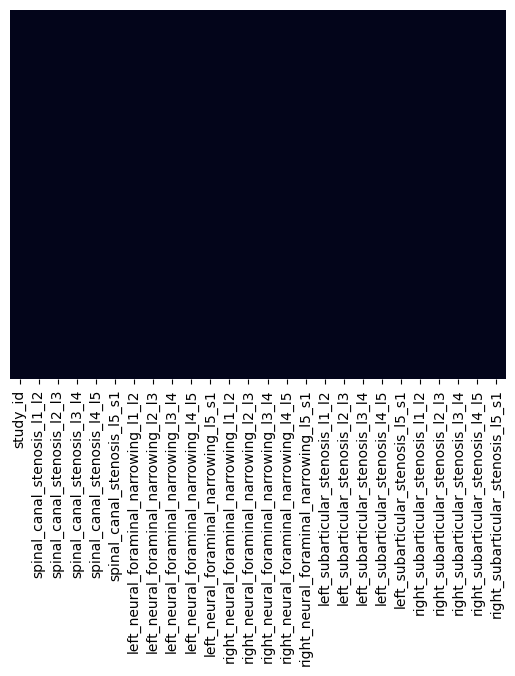

In [36]:
sns.heatmap(train_df_cleaned.isnull(),yticklabels=False,cbar=False)

# 3. Adjust Coordinate and Series Description Files:

In [37]:
# Load the coordinate and series description files
# coordinate_df = pd.read_csv('train_label_coordinates.csv')
# series_desc_df = pd.read_csv('train_series_descriptions.csv')

# Get the study_ids from the cleaned train_df
valid_study_ids = set(train_df_cleaned['study_id'])

# Filter coordinate and series description files to only include valid study_ids
coordinate_df_cleaned = coordinate_df[coordinate_df['study_id'].isin(valid_study_ids)]
series_desc_df_cleaned = series_desc_df[series_desc_df['study_id'].isin(valid_study_ids)]

# Save the cleaned versions
coordinate_df_cleaned.to_csv('train_label_coordinates_cleaned.csv', index=False)
series_desc_df_cleaned.to_csv('train_series_descriptions_cleaned.csv', index=False)

In [38]:
coordinate_df_cleaned.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


In [39]:
coordinate_df_cleaned['condition'].value_counts()

condition
Left Neural Foraminal Narrowing     9030
Right Neural Foraminal Narrowing    9029
Right Subarticular Stenosis         9028
Spinal Canal Stenosis               9027
Left Subarticular Stenosis          9025
Name: count, dtype: int64

In [40]:
coordinate_df_cleaned['level'].value_counts()

level
L2/L3    9032
L3/L4    9032
L1/L2    9030
L4/L5    9028
L5/S1    9017
Name: count, dtype: int64

In [41]:
series_desc_df_cleaned.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [42]:
series_desc_df_cleaned['series_description'].value_counts()

series_description
Axial T2            2156
Sagittal T1         1814
Sagittal T2/STIR    1808
Name: count, dtype: int64

In [43]:
series_desc_df_cleaned.isnull().sum()

study_id              0
series_id             0
series_description    0
dtype: int64

In [44]:
coordinate_df_cleaned.isnull().sum()

study_id           0
series_id          0
instance_number    0
condition          0
level              0
x                  0
y                  0
dtype: int64

In [45]:
coordinate_df_cleaned.head(5)

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


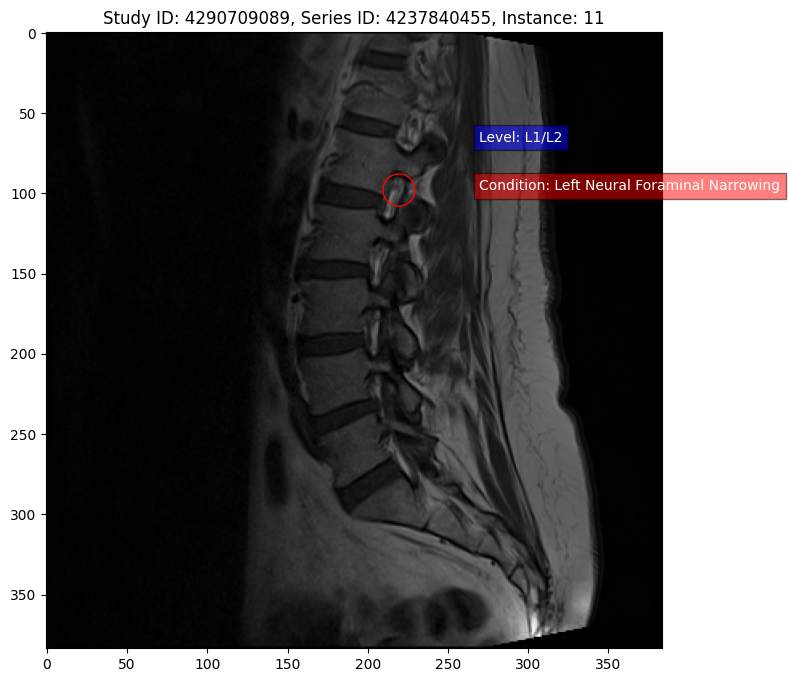

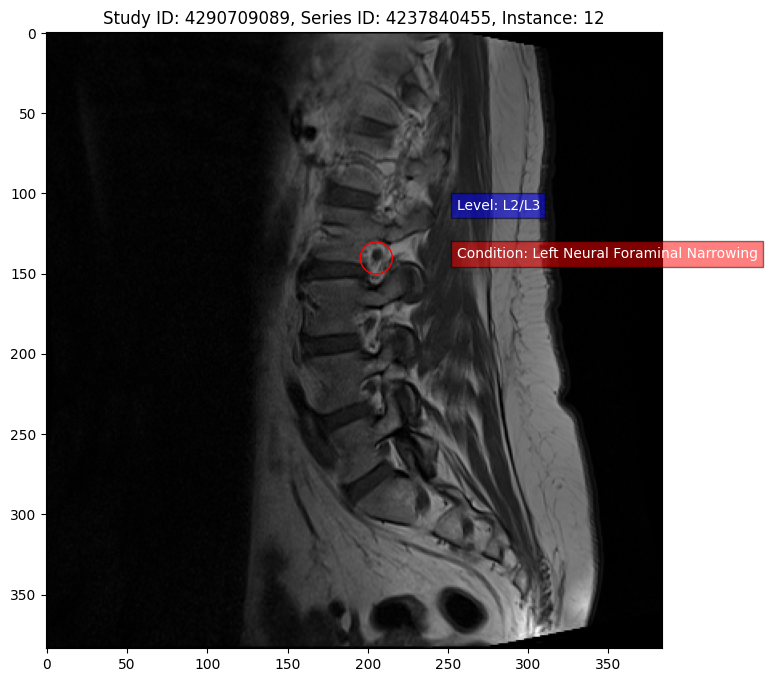

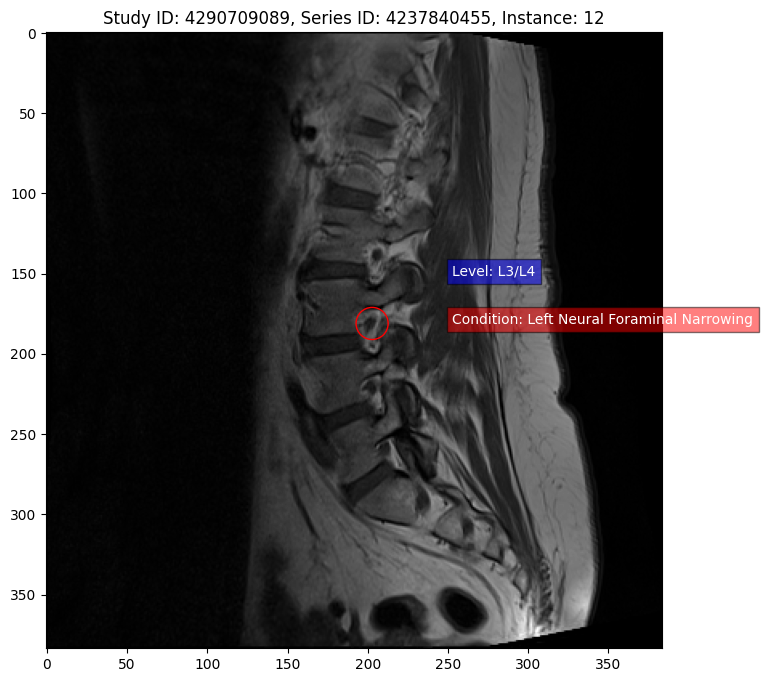

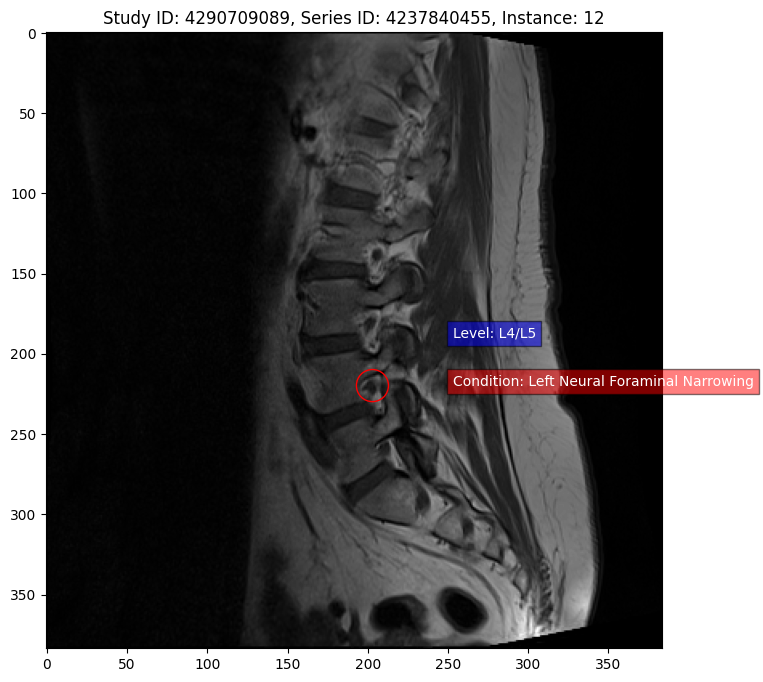

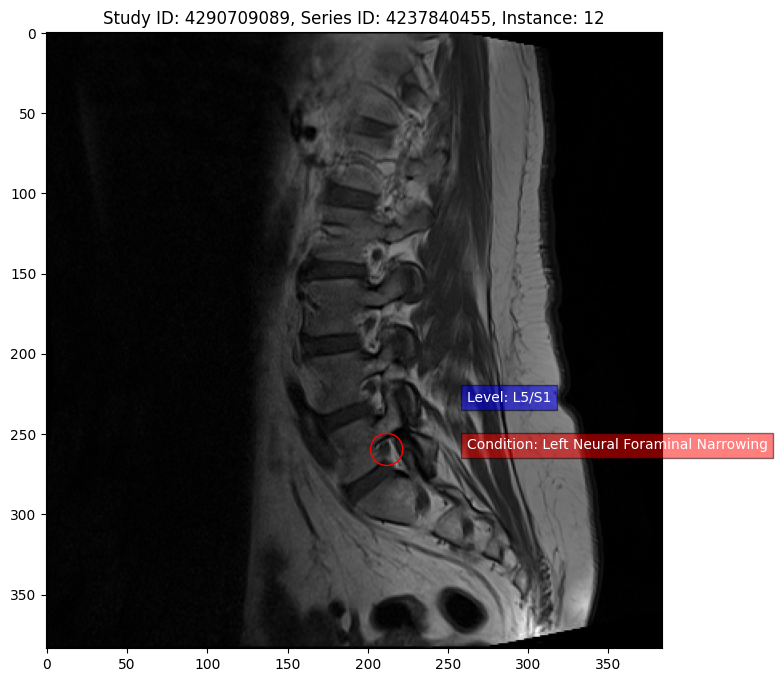

In [46]:
import pydicom
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pandas as pd
import os

# # Load the cleaned coordinate data
# coordinate_df_cleaned = pd.read_csv('train_label_coordinates_cleaned.csv')

# Define a function to load the DICOM image
def load_dicom_image(study_id, series_id, instance_number):
    dcm_path = f'/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images/{study_id}/{series_id}/{instance_number}.dcm'
    dicom_file = pydicom.dcmread(dcm_path)
    pixel_array = dicom_file.pixel_array
    return pixel_array

# Define a function to plot the image and overlay the coordinates
def plot_with_overlay(study_id, series_id, instance_number, x, y,condition,level):
    # Load the DICOM image
    image = load_dicom_image(study_id, series_id, instance_number)
    
    # Create a plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # Display the image
    ax.imshow(image, cmap='gray')
    
    # Overlay the coordinates as a circle
    ax.add_patch(Circle((x, y), radius=10, color='red', fill=False))
    
    # Set the title and labels
    ax.set_title(f'Study ID: {study_id}, Series ID: {series_id}, Instance: {instance_number}')
    
    
    # Add the labels for condition and level
    ax.text(x + 50, y, f'Condition: {condition}', color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.5))
    ax.text(x + 50, y - 30, f'Level: {level}', color='white', fontsize=10, bbox=dict(facecolor='blue', alpha=0.5))
    plt.show()

# Iterate over a few rows of the coordinate_df_cleaned to visualize the labeled regions
for index, row in coordinate_df_cleaned.tail(5).iterrows():
    study_id = row['study_id']
    series_id = row['series_id']
    instance_number = row['instance_number']
    x = row['x']
    y = row['y']
    condition= row['condition']
    level= row['level']
    
    # Plot the image with overlay
    plot_with_overlay(study_id, series_id, instance_number, x, y,condition,level)

In [47]:
train_df_cleaned.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


In [48]:
from sklearn.model_selection import train_test_split

# Define the target severity column (one-hot encoded in 'train_df_cleaned')
target_columns = ['Normal/Mild', 'Moderate', 'Severe']

# Stratify based on severity
y = train_df_cleaned[target_columns].idxmax(axis=1)  # Convert one-hot to categorical for stratification

# Perform stratified train-test split (80% train, 20% validation)
train_df, val_df = train_test_split(
    train_df_cleaned, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Display results
print(f"Training set size: {train_df.shape[0]}")
print(f"Validation set size: {val_df.shape[0]}")

KeyError: "None of [Index(['Normal/Mild', 'Moderate', 'Severe'], dtype='object')] are in the [columns]"

In [52]:
import os

train_dir = '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images'

# Get the list of files in the directory
files_in_train_dir = os.listdir(train_dir)

# Print the list of files
print(len(files_in_train_dir))

1975


In [53]:
import os

def get_directory_info(directory_path):
    top_level_folders = 0
    subfolders = 0
    total_files = 0

    # Walk through the directory
    for dirpath, dirnames, filenames in os.walk(directory_path):
        # If we are at the root level, count top-level folders
        if dirpath == directory_path:
            top_level_folders += len(dirnames)
        else:
            # If we are not at the root level, count subfolders
            subfolders += len(dirnames)
        
        # Count the files
        total_files += len(filenames)

    return top_level_folders, subfolders, total_files

# Specify the directory path
directory_path = '/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images'

# Get the folder and file count
top_level_folders, subfolders, total_files = get_directory_info(directory_path)

# Print the information
print(f"Top-level folders: {top_level_folders}")
print(f"Subfolders (within folders): {subfolders}")
print(f"Total files: {total_files}")

KeyboardInterrupt: 

In [ ]:
os.walk('/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images')

In [ ]:
sample_submission.head()

In [54]:
import pandas as pd

# Start from your cleaned train_df_cleaned (or train_df)
df = train_df_cleaned.copy()

# 1) Melt from wide to long: one row per (study_id, condition)
condition_cols = [c for c in df.columns if c != 'study_id']

long_df = df.melt(
    id_vars=['study_id'],
    value_vars=condition_cols,
    var_name='condition',      # e.g. 'left_neural_foraminal_narrowing_l1_l2'
    value_name='severity_str'  # e.g. 'Normal/Mild'
)

# 2) Normalize severity strings to match submission column names
mapping = {
    'Normal/Mild': 'normal_mild',
    'Moderate': 'moderate',
    'Severe': 'severe'
}
long_df['severity'] = long_df['severity_str'].map(mapping)

# 3) Create row_id in the same format as sample_submission
long_df['row_id'] = (
    long_df['study_id'].astype(str) + '_' + long_df['condition']
)

# 4) One-hot encode the severity into 3 columns
one_hot = pd.get_dummies(long_df['severity'])

# Ensure all three columns exist
for col in ['normal_mild', 'moderate', 'severe']:
    if col not in one_hot.columns:
        one_hot[col] = 0

# 5) Final training label table in submission-style format
train_labels_long = pd.concat(
    [long_df[['row_id']], one_hot[['normal_mild', 'moderate', 'severe']]],
    axis=1
)

train_labels_long.head(20)


,row_id,normal_mild,moderate,severe
0,4003253_spinal_canal_stenosis_l1_l2,True,False,False
1,4646740_spinal_canal_stenosis_l1_l2,True,False,False
2,7143189_spinal_canal_stenosis_l1_l2,True,False,False
3,8785691_spinal_canal_stenosis_l1_l2,True,False,False
4,10728036_spinal_canal_stenosis_l1_l2,True,False,False
5,11340341_spinal_canal_stenosis_l1_l2,True,False,False
6,11943292_spinal_canal_stenosis_l1_l2,True,False,False
7,13317052_spinal_canal_stenosis_l1_l2,True,False,False
8,22191399_spinal_canal_stenosis_l1_l2,True,False,False
9,26342422_spinal_canal_stenosis_l1_l2,True,False,False


In [ ]:
!ls /kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images | wc -l


In [ ]:
!ls /kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images


In [50]:
import os

root = "/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images"

# List a few study IDs
study_ids = sorted(os.listdir(root))[:5]
print("Sample study_ids:", study_ids)

for sid in study_ids:
    study_path = os.path.join(root, sid)
    series_ids = os.listdir(study_path)
    print(f"\nStudy {sid} has {len(series_ids)} series:", series_ids)
    
    # For the first series in this study, list a few DICOM files
    first_series = series_ids[0]
    series_path = os.path.join(study_path, first_series)
    dcm_files = [f for f in os.listdir(series_path) if f.endswith(".dcm")]
    print(f"  Series {first_series} has {len(dcm_files)} slices, example:", dcm_files[:5])
    break  # remove this break if you want to print all 5 studies


Sample study_ids: ['100206310', '1002894806', '1004726367', '1008446160', '1009445512']

Study 100206310 has 3 series: ['1792451510', '1012284084', '2092806862']
  Series 1792451510 has 18 slices, example: ['12.dcm', '18.dcm', '9.dcm', '14.dcm', '11.dcm']


In [51]:
# For that same study, see what each series_id means
# sid = study_ids[0]
sid = 100206310
series_desc_df[series_desc_df["study_id"] == int(sid)]


,study_id,series_id,series_description
144,100206310,1012284084,Axial T2
145,100206310,1792451510,Sagittal T2/STIR
146,100206310,2092806862,Sagittal T1


In [55]:
import pandas as pd

# Start from your cleaned ones
labels_df = train_df_cleaned.copy()
series_df = series_desc_df_cleaned.copy()

mri_types = {
    "sag_t2": "Sagittal T2/STIR",
    "sag_t1": "Sagittal T1",
    "ax_t2": "Axial T2",
}

dfs_by_mri = {}

for key, desc in mri_types.items():
    # 1) Filter to only that MRI sequence
    tmp = series_df[series_df["series_description"] == desc][["study_id", "series_id"]]
    
    # (Optional) If there are duplicate series per study/type, keep just one
    tmp = tmp.drop_duplicates(subset=["study_id"])
    
    # 2) Merge with labels so each row has study_id, series_id (of this type), and all label columns
    df_mri = labels_df.merge(tmp, on="study_id", how="inner")
    
    # Rename series_id so it's clear
    df_mri = df_mri.rename(columns={"series_id": f"series_id_{key}"})
    
    dfs_by_mri[key] = df_mri

# Unpack for convenience
df_sag_t2 = dfs_by_mri["sag_t2"]
df_sag_t1 = dfs_by_mri["sag_t1"]
df_ax_t2  = dfs_by_mri["ax_t2"]

df_sag_t2.head()


,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1,series_id_sag_t2
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,702807833
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild,3666319702
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,132939515
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,481125819
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,3491739931


In [56]:
# 1. Check if study_id is unique
study_id_unique = df_sag_t2["study_id"].is_unique
print("Are study_id values unique in df_sag_t2? →", study_id_unique)

# 2. Check if series_id_sag_t2 is unique
series_unique = df_sag_t2["series_id_sag_t2"].is_unique
print("Are series_id_sag_t2 values unique in df_sag_t2? →", series_unique)

# If not unique, count duplicates
if not study_id_unique:
    print("\nDuplicate study_ids:")
    print(df_sag_t2["study_id"].value_counts()[df_sag_t2["study_id"].value_counts() > 1])

if not series_unique:
    print("\nDuplicate series_id_sag_t2:")
    print(df_sag_t2["series_id_sag_t2"].value_counts()[df_sag_t2["series_id_sag_t2"].value_counts() > 1])


Are study_id values unique in df_sag_t2? → True
Are series_id_sag_t2 values unique in df_sag_t2? → True


In [60]:
import pandas as pd

# Start from your cleaned train_df
df = train_df_cleaned.copy()

# 1) Melt from wide to long: one row per (study_id, condition)
condition_cols = [c for c in df.columns if c != 'study_id']

long_df = df.melt(
    id_vars=['study_id'],
    value_vars=condition_cols,
    var_name='condition',      # e.g. 'left_neural_foraminal_narrowing_l1_l2'
    value_name='severity_str'  # e.g. 'Normal/Mild'
)

# 2) Normalize severity strings to match submission column names
mapping = {
    'Normal/Mild': 'normal_mild',
    'Moderate': 'moderate',
    'Severe': 'severe'
}
long_df['severity'] = long_df['severity_str'].map(mapping)

# 3) Create row_id in the same format as sample_submission
long_df['row_id'] = (
    long_df['study_id'].astype(str) + '_' + long_df['condition']
)

# 4) One-hot encode the severity into 3 columns
one_hot = pd.get_dummies(long_df['severity'])

# Ensure all three columns exist
for col in ['normal_mild', 'moderate', 'severe']:
    if col not in one_hot.columns:
        one_hot[col] = 0

# 5) Final training label table in submission-style format
#    (keep study_id & condition too, they’re useful for merging later)
train_labels_long = pd.concat(
    [long_df[['study_id', 'condition', 'row_id']],
     one_hot[['normal_mild', 'moderate', 'severe']]],
    axis=1
)

train_labels_long.head(20)


,study_id,condition,row_id,normal_mild,moderate,severe
0,4003253,spinal_canal_stenosis_l1_l2,4003253_spinal_canal_stenosis_l1_l2,True,False,False
1,4646740,spinal_canal_stenosis_l1_l2,4646740_spinal_canal_stenosis_l1_l2,True,False,False
2,7143189,spinal_canal_stenosis_l1_l2,7143189_spinal_canal_stenosis_l1_l2,True,False,False
3,8785691,spinal_canal_stenosis_l1_l2,8785691_spinal_canal_stenosis_l1_l2,True,False,False
4,10728036,spinal_canal_stenosis_l1_l2,10728036_spinal_canal_stenosis_l1_l2,True,False,False
5,11340341,spinal_canal_stenosis_l1_l2,11340341_spinal_canal_stenosis_l1_l2,True,False,False
6,11943292,spinal_canal_stenosis_l1_l2,11943292_spinal_canal_stenosis_l1_l2,True,False,False
7,13317052,spinal_canal_stenosis_l1_l2,13317052_spinal_canal_stenosis_l1_l2,True,False,False
8,22191399,spinal_canal_stenosis_l1_l2,22191399_spinal_canal_stenosis_l1_l2,True,False,False
9,26342422,spinal_canal_stenosis_l1_l2,26342422_spinal_canal_stenosis_l1_l2,True,False,False


In [61]:
import numpy as np
import pandas as pd

# Start from your df_sag_t2
df = df_sag_t2.copy()

id_cols = ["study_id", "series_id_sag_t2"]
label_cols = [c for c in df.columns if c not in id_cols]

print("Num conditions:", len(label_cols))
print("Example label columns:", label_cols[:5])

severity_map = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

for col in label_cols:
    df[col] = df[col].map(severity_map)

df[label_cols].head()


Num conditions: 25
Example label columns: ['spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4', 'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1']


,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,1,2,0,0,0,0,1,1,...,0,0,0,2,0,0,1,1,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [62]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

len(train_df), len(val_df)


(1446, 362)

# Dataset Prep

In [63]:
import os
import glob
import pydicom
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_ROOT = "/kaggle/input/rsna-2024-lumbar-spine-degenerative-classification/train_images"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Common transform: resize, normalize
img_transform = transforms.Compose([
    transforms.ToTensor(),              # H×W → 1×H×W, values 0–1
    transforms.Resize((224, 224)),
    transforms.Normalize([0.5], [0.5])  # simple normalization
])


class SagT2Dataset(Dataset):
    def __init__(self, df, label_cols, img_root=IMG_ROOT, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.img_root = img_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_middle_slice(self, study_id, series_id):
        series_path = os.path.join(self.img_root, str(study_id), str(series_id))
        dcm_files = sorted(glob.glob(os.path.join(series_path, "*.dcm")))
        if len(dcm_files) == 0:
            raise RuntimeError(f"No DICOM files in {series_path}")
        mid_idx = len(dcm_files) // 2
        dcm_path = dcm_files[mid_idx]
        dcm = pydicom.dcmread(dcm_path)
        img = dcm.pixel_array.astype(np.float32)
        # Min-max normalize per-slice for safety
        img = img - img.min()
        if img.max() > 0:
            img = img / img.max()
        return img  # H×W, float32 in [0,1]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row["study_id"]
        series_id = row["series_id_sag_t2"]
        
        img = self._load_middle_slice(study_id, series_id)

        if self.transform is not None:
            img = self.transform(img)  # 1×H×W

        # convert to 3-channel by repeating
        img = img.repeat(3, 1, 1)     # 3×H×W

        # labels: vector of length num_conditions, ints 0/1/2
        labels = torch.tensor(row[self.label_cols].values, dtype=torch.long)

        return img, labels


train_dataset = SagT2Dataset(train_df, label_cols, transform=img_transform)
val_dataset   = SagT2Dataset(val_df, label_cols, transform=img_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

len(train_dataset), len(val_dataset)


Device: cpu


(1446, 362)

In [66]:
import torch.nn as nn
import torchvision.models as models

num_conditions = len(label_cols)
num_classes = 3

class MultiTaskResNet18(nn.Module):
    def __init__(self, num_conditions, num_classes=3):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # adjust first conv to single-channel input (we already repeat to 3 channels, so this is optional;
        # if you keep 3 channels, you can skip modifying conv1)
        # Here we'll keep standard 3-channel conv1 since we repeat img to 3 channels.

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_conditions * num_classes)

        self.num_conditions = num_conditions
        self.num_classes = num_classes

    def forward(self, x):
        # x: [B, 3, 224, 224]
        out = self.backbone(x)  # [B, num_conditions * num_classes]
        out = out.view(-1, self.num_conditions, self.num_classes)  # [B, C, 3]
        return out

model = MultiTaskResNet18(num_conditions=num_conditions, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [67]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)  # [B, C]

            outputs = model(imgs)       # [B, C, 3]
            # reshape to [B*C, 3] and [B*C]
            B, C, K = outputs.shape
            logits = outputs.view(B * C, K)
            target = labels.view(B * C)

            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    acc = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average="macro")

    return acc, f1_macro


num_epochs = 3  # start small; you can increase

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)  # [B, C]

        optimizer.zero_grad()

        outputs = model(imgs)       # [B, C, 3]
        B, C, K = outputs.shape

        logits = outputs.view(B * C, K)   # [B*C, 3]
        target = labels.view(B * C)       # [B*C]

        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_dataset)
    val_acc, val_f1 = evaluate(model, val_loader, device)

    print(f"Epoch {epoch}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Val F1(macro): {val_f1:.4f}")


Epoch 1/3 | Train Loss: 0.6248 | Val Acc: 0.7801 | Val F1(macro): 0.3216
Epoch 2/3 | Train Loss: 0.5149 | Val Acc: 0.7812 | Val F1(macro): 0.3703
Epoch 3/3 | Train Loss: 0.4563 | Val Acc: 0.7734 | Val F1(macro): 0.4145
